Loading data from D:\MASTER THESIS DATA\bitmex\processed_5m_bidask\...
Pivoting data matrices...
Data Loaded. Shape: (298081, 244)
Funding Rates Loaded.

[START] Case: Fast_4h
Processed up to 2025-11-01 00:00:00 | CumPnL: 21.25     

RESULTS: Fast_4h
Total Return (%): 106.26
Max Drawdown (%): -1.52
Sharpe Ratio: 7.7
Final PnL: 21.25


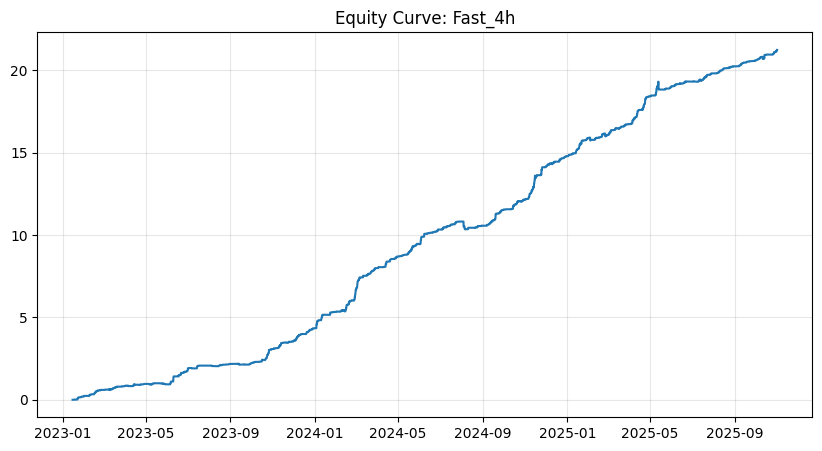


[START] Case: Medium_8h
Processed up to 2025-11-01 00:00:00 | CumPnL: 20.42     

RESULTS: Medium_8h
Total Return (%): 102.08
Max Drawdown (%): -1.16
Sharpe Ratio: 6.71
Final PnL: 20.42


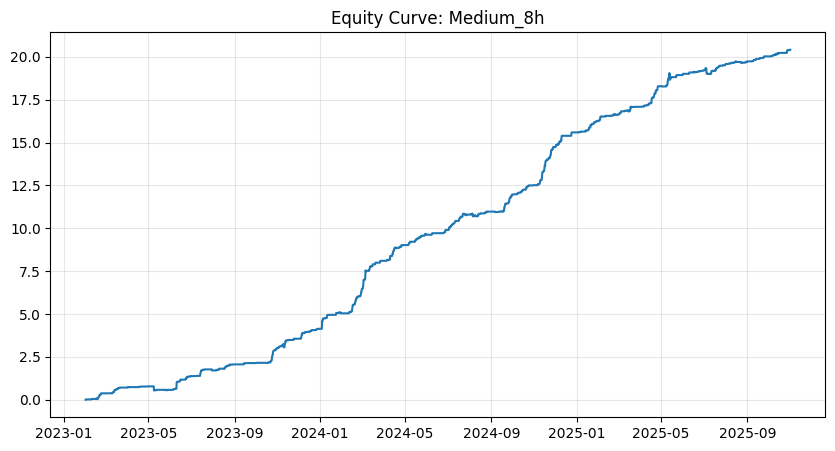


[START] Case: Slow_12h
Processed up to 2025-11-01 00:00:00 | CumPnL: 14.87     

RESULTS: Slow_12h
Total Return (%): 74.33
Max Drawdown (%): -1.8
Sharpe Ratio: 6.13
Final PnL: 14.87


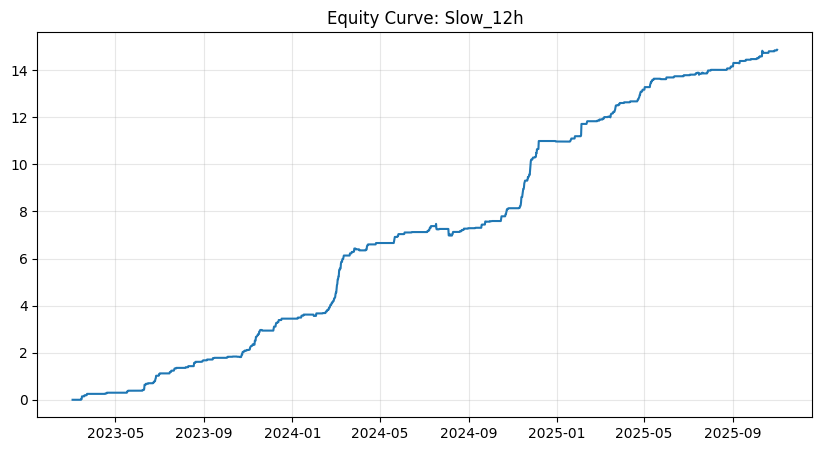


[START] Case: Daily_24h
Processed up to 2025-11-01 00:00:00 | CumPnL: 12.16     

RESULTS: Daily_24h
Total Return (%): 60.8
Max Drawdown (%): -0.95
Sharpe Ratio: 5.54
Final PnL: 12.16


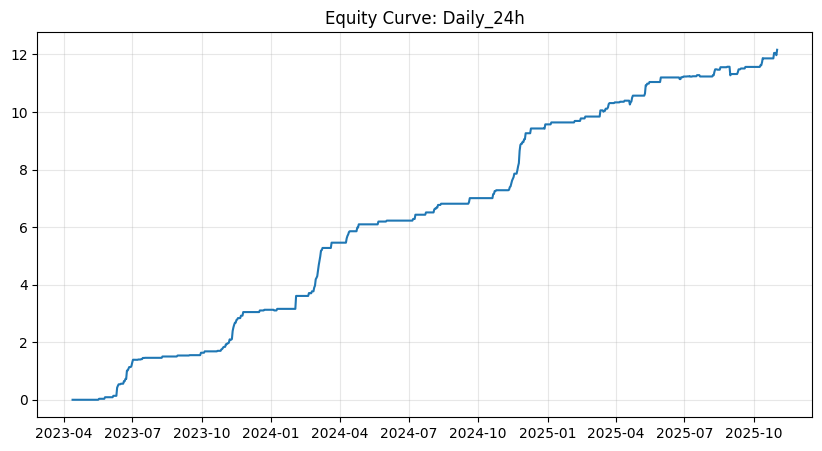

In [2]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    # --- PATHS ---
    DATA_PATH = "D:\\MASTER THESIS DATA\\bitmex\\processed_5m_bidask\\"
    FUNDING_PATH = "D:\\MASTER THESIS DATA\\bitmex\\funding_rates\\"
    OUTPUT_DIR = "D:\\MASTER THESIS DATA\\results\\"
    
    # --- DATES ---
    START_DATE = "2023-01-01"
    END_DATE = "2025-11-01"
    
    # --- STRATEGY PARAMS ---
    CORR_THRESHOLD = 0.90    
    MAX_PAIRS = 10           
    
    # --- COSTS & LIMITS ---
    TC_BPS = 5               # 5 bps per leg
    MAX_SPREAD_PCT = 0.05    # 5% max spread filter
    COMMITTED_CAPITAL = 20   # Baseline capital unit
    
    # --- DATA ---
    FFILL_LIMIT = 288        
    INCLUDE_FUNDING = True

if not os.path.exists(Config.OUTPUT_DIR):
    os.makedirs(Config.OUTPUT_DIR)

TEST_CASES =[
    {"name": "Fast_4h",   "l_freq": "4h",  "window_l": 14, "window_y": 3},
    {"name": "Medium_8h", "l_freq": "8h",  "window_l": 30, "window_y": 7},
    {"name": "Slow_12h", "l_freq": "12h", "window_l": 60, "window_y": 14},
    {"name": "Daily_24h", "l_freq": "24h", "window_l": 100, "window_y": 30}
]

# ==========================================
# 2. DATA HANDLERS
# ==========================================
class FastDataHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_mid = self.df_bid = self.df_ask = None

    def load_data(self):
        print(f"Loading data from {self.folder_path}...")
        all_files = glob.glob(os.path.join(self.folder_path, "**", "*.parquet"), recursive=True)
        q = pl.scan_parquet(all_files).with_columns(pl.col("timestamp").cast(pl.Datetime))
        
        q = q.with_columns([
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("mid_price")).otherwise(None).alias("mid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("bid_price")).otherwise(None).alias("bid_price"),
            pl.when(pl.col("is_valid").cast(pl.Boolean)).then(pl.col("ask_price")).otherwise(None).alias("ask_price")
        ])
        
        df_long = q.collect()
        s_dt = datetime.strptime(Config.START_DATE, "%Y-%m-%d")
        e_dt = datetime.strptime(Config.END_DATE, "%Y-%m-%d")
        df_long = df_long.filter((pl.col("timestamp") >= s_dt) & (pl.col("timestamp") <= e_dt))
        
        print("Pivoting data matrices...")
        self.df_mid = df_long.pivot(index="timestamp", on="symbol", values="mid_price", aggregate_function="last").sort("timestamp")
        self.df_bid = df_long.pivot(index="timestamp", on="symbol", values="bid_price", aggregate_function="last").sort("timestamp")
        self.df_ask = df_long.pivot(index="timestamp", on="symbol", values="ask_price", aggregate_function="last").sort("timestamp")
        
        grid = pl.datetime_range(self.df_mid["timestamp"].min(), self.df_mid["timestamp"].max(), interval="5m", eager=True).alias("timestamp").to_frame()
        grid = grid.with_columns(pl.col("timestamp").cast(self.df_mid["timestamp"].dtype))
        
        def align(df):
            return grid.join(df, on="timestamp", how="left").with_columns(pl.all().forward_fill(limit=Config.FFILL_LIMIT))

        self.df_mid = align(self.df_mid)
        self.df_bid = align(self.df_bid)
        self.df_ask = align(self.df_ask)
        print(f"Data Loaded. Shape: {self.df_mid.shape}")

    def get_slices(self, start, end):
        mask = (self.df_mid["timestamp"] >= start) & (self.df_mid["timestamp"] <= end)
        return self.df_mid.filter(mask), self.df_bid.filter(mask), self.df_ask.filter(mask)

class FundingHandler:
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.df_funding = None
        
    def load_rates(self):
        try:
            q = pl.scan_csv(os.path.join(self.folder_path, "*.csv"))
            self.df_funding = (
                q.with_columns([pl.col("timestamp").str.replace("T", " ").str.replace("Z", "").str.to_datetime(strict=False).dt.replace_time_zone(None)])
                .drop_nulls(subset=["timestamp"]).select(["timestamp", "symbol", "fundingRate"])
                .collect().pivot(index="timestamp", on="symbol", values="fundingRate", aggregate_function="last").sort("timestamp")
            )
            print("Funding Rates Loaded.")
        except: print("Funding Load Failed.")
        
    def get_rates_slice(self, start, end):
        if self.df_funding is None: return None
        return self.df_funding.filter((pl.col("timestamp") >= start) & (pl.col("timestamp") <= end))

# ==========================================
# 3. MATH (OU CALIBRATION)
# ==========================================
class OUCalibrator:
    @staticmethod
    def fit(spread, dt=1.0):
        if np.isnan(spread).any(): return {'success': False}
        n = len(spread)
        if n < 15: return {'success': False}
        
        x, y = spread[:-1], spread[1:]
        denom = (n-1) * np.sum(x*x) - np.sum(x)**2
        if denom == 0: return {'success': False}
        
        b = ((n-1) * np.sum(x*y) - np.sum(x) * np.sum(y)) / denom
        a = (np.sum(y) - b * np.sum(x)) / (n-1)
        
        if b >= 0.999 or b <= 0.0: return {'success': False}
        
        theta = -np.log(b) / dt
        mu = a / (1 - b)
        sigma = np.std(y - (a + b * x)) * np.sqrt((2 * theta) / (1 - b**2))
        return {'theta': theta, 'mu': mu, 'sigma': sigma, 'success': True}

# ==========================================
# 4. STATS & EVALUATION
# ==========================================
def calculate_stats(df_equity, capital):
    if df_equity.empty: return {}
    df = df_equity.copy()
    df['roi_pct'] = (df['pnl'] / capital) * 100
    df['date'] = pd.to_datetime(df['time']).dt.date
    daily_rets = df.groupby('date')['roi_pct'].last().diff().fillna(0)
    
    total_ret = df['roi_pct'].iloc[-1]
    equity_series = df['pnl'] + capital
    peak = equity_series.cummax()
    drawdown = (equity_series - peak) / peak
    max_dd = drawdown.min() * 100
    
    sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(365) if daily_rets.std() != 0 else 0
    return {
        "Total Return (%)": round(total_ret, 2),
        "Max Drawdown (%)": round(max_dd, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Final PnL": round(df['pnl'].iloc[-1], 2)
    }

# ==========================================
# 5. STRATEGY ENGINE
# ==========================================
class StrategyEngine:
    def __init__(self, dh, fh, params):
        self.dh, self.fh, self.p = dh, fh, params
        self.equity_curve =[]
        self.logs =[]

    def get_symbol_root(self, symbol):
        bases =['USDT', 'USDC', 'USD', 'EUR', 'BTC', 'ETH']
        bases.sort(key=len, reverse=True)
        for base in bases:
            if symbol.endswith(base): return symbol[:-len(base)]
        return symbol

    # ADDED rate_a and rate_b for the funding log output
    def log_trade(self, time, pair, type_, price_a, price_b, cost, pnl_change, comment="", rate_a=None, rate_b=None):
        self.logs.append({
            "Test_Case": self.p['name'],
            "Time": time,
            "Pair": f"{pair[0]}-{pair[1]}",
            "Type": type_,
            "Price_A": price_a,
            "Price_B": price_b,
            "Rate_A": rate_a,
            "Rate_B": rate_b,
            "Cost": cost,
            "PnL_Change": pnl_change,
            "Comment": comment
        })

    def run(self):
        print(f"\n[START] Case: {self.p['name']}")
        df_L_agg = self.dh.df_mid.group_by_dynamic("timestamp", every=self.p['l_freq']).agg(pl.all().last())
        trend_dates = df_L_agg["timestamp"].to_list()
        
        start_idx = next(i for i, d in enumerate(trend_dates) if d - trend_dates[0] > timedelta(days=self.p['window_l']))
        cumulative_pnl = 0.0
        all_syms =[c for c in self.dh.df_mid.columns if c != "timestamp"]
        
        for i in range(start_idx, len(trend_dates)-1):
            curr_t, next_t = trend_dates[i], trend_dates[i+1]
            
            l_start = curr_t - timedelta(days=self.p['window_l'])
            y_start = curr_t - timedelta(days=self.p['window_y'])
            
            df_L_hist = df_L_agg.filter((pl.col("timestamp") >= l_start) & (pl.col("timestamp") <= curr_t))
            df_Y_hist, _, _ = self.dh.get_slices(y_start, curr_t)
            df_t_mid, df_t_bid, df_t_ask = self.dh.get_slices(curr_t, next_t)
            if df_t_mid.height < 5: continue

            valid_syms =[s for s in all_syms if df_Y_hist[s].null_count() == 0]
            if len(valid_syms) < 2: continue
            
            corr_mat = df_Y_hist.select(valid_syms).corr().to_numpy()
            cands =[]
            
            # --- RANKING ---
            for r in range(len(valid_syms)):
                for c in range(r+1, len(valid_syms)):
                    sym_a, sym_b = valid_syms[r], valid_syms[c]
                    if self.get_symbol_root(sym_a) == self.get_symbol_root(sym_b): continue
                    if corr_mat[r,c] < Config.CORR_THRESHOLD: continue
                    
                    l_vals = np.log(df_L_hist[sym_a].to_numpy()) - np.log(df_L_hist[sym_b].to_numpy())
                    pL = OUCalibrator.fit(l_vals, dt=1.0)
                    if not pL['success']: continue
                    
                    y_vals = np.log(df_Y_hist[sym_a].to_numpy()) - np.log(df_Y_hist[sym_b].to_numpy())
                    pY = OUCalibrator.fit(y_vals, dt=1/288) 
                    if not pY['success']: continue
                    
                    var_L = (pL['sigma']**2 / (2*pL['theta']))
                    var_Y = (pY['sigma']**2 / (2*pY['theta']))
                    
                    target_mean = (l_vals[-1] + l_vals[-2]) / 2.0
                    
                    cands.append({
                        'pair': (sym_a, sym_b),
                        'score': var_Y / (var_L + 1e-9),
                        'target': target_mean,
                        'eps': np.percentile(np.abs(np.diff(l_vals)), 98)
                    })
            
            # --- UNIQUE ASSET FILTER ---
            cands.sort(key=lambda x: x['score'], reverse=True)
            final_selection =[]
            active_roots = set()
            
            for cand in cands:
                if len(final_selection) >= Config.MAX_PAIRS: break
                sa, sb = cand['pair']
                ra, rb = self.get_symbol_root(sa), self.get_symbol_root(sb)
                
                if ra in active_roots or rb in active_roots: continue
                
                active_roots.add(ra); active_roots.add(rb)
                final_selection.append(cand)
            
            if not final_selection: continue
            top_pairs = pd.DataFrame(final_selection)
            
            # --- EXECUTE SESSION ---
            session_pnl = self.trade_session(top_pairs, df_t_mid, df_t_bid, df_t_ask, curr_t, next_t)
            cumulative_pnl += session_pnl
            self.equity_curve.append({'time': next_t, 'pnl': cumulative_pnl})

            # FIX: Print the Cumulative PnL AFTER the session has executed
            print(f"Processed up to {next_t} | CumPnL: {cumulative_pnl:.2f}     ", end='\r')
            
        print() # To break the carriage return line
        return pd.DataFrame(self.equity_curve)

    def trade_session(self, pairs_df, df_mid, df_bid, df_ask, start_time, end_time):
        total_sess_pnl = 0.0
        df_fund = self.fh.get_rates_slice(start_time, end_time) if Config.INCLUDE_FUNDING else None

        for _, row in pairs_df.iterrows():
            sym_a, sym_b = row['pair']
            target, eps = row['target'], row['eps']
            upper, lower = target + eps, target - eps
            
            ts = df_mid["timestamp"].to_numpy()
            ma, mb = df_mid[sym_a].to_numpy(), df_mid[sym_b].to_numpy()
            ba, bb = df_bid[sym_a].to_numpy(), df_bid[sym_b].to_numpy()
            aa, ab = df_ask[sym_a].to_numpy(), df_ask[sym_b].to_numpy()
            
            def safe_log(arr):
                with np.errstate(divide='ignore', invalid='ignore'):
                    return np.log(np.where(arr > 0, arr, np.nan))
            
            lma, lmb = safe_log(ma), safe_log(mb)
            y_spread = lma - lmb 
            
            # State
            curr = 0 
            realized_pnl = 0.0
            floating_pnl = 0.0
            
            entry_pa = 0.0; entry_pb = 0.0
            val_a = 0.0; val_b = 0.0
            
            pos_history = np.zeros(len(ts)) 
            
            capital_per_leg = 1.0 
            fee_rate = Config.TC_BPS / 10000.0
            
            for t in range(len(ts)):
                v = y_spread[t]
                
                is_nan_row = np.isnan(v) or np.isnan(ba[t]) or np.isnan(bb[t])
                safe_spread = False
                if not is_nan_row:
                    s_a = (aa[t] - ba[t]) / ba[t]
                    s_b = (ab[t] - bb[t]) / bb[t]
                    safe_spread = (s_a < Config.MAX_SPREAD_PCT and s_b < Config.MAX_SPREAD_PCT)
                
                signal = curr
                if not is_nan_row and safe_spread:
                    if curr == 0:
                        if v > upper: signal = -1
                        elif v < lower: signal = 1
                    elif curr == -1 and v < target: signal = 0
                    elif curr == 1 and v > target: signal = 0
                
                if t == len(ts) - 1 and curr != 0: signal = 0 
                
                # --- ARITHMETIC VALUATION ---
                if curr != 0:
                    if is_nan_row: pass 
                    elif not safe_spread: val_a, val_b = ma[t], mb[t] 
                    else:
                        val_a = ba[t] if curr == 1 else aa[t]
                        val_b = ab[t] if curr == 1 else bb[t]
                        
                    if curr == 1:
                        ret_a = (val_a - entry_pa) / entry_pa
                        ret_b = (entry_pb - val_b) / entry_pb
                    else:
                        ret_a = (entry_pa - val_a) / entry_pa
                        ret_b = (val_b - entry_pb) / entry_pb
                        
                    floating_pnl = capital_per_leg * ret_a + capital_per_leg * ret_b
                    
                    if not is_nan_row and safe_spread:
                        if ret_a <= -0.99 or ret_b <= -0.99:
                            exit_fee = capital_per_leg * 2 * fee_rate
                            realized_pnl += floating_pnl - exit_fee
                            self.log_trade(ts[t], (sym_a, sym_b), "LIQUIDATION", val_a, val_b, exit_fee, floating_pnl - exit_fee, "Leg Hit -99%")
                            curr, signal, floating_pnl = 0, 0, 0.0
                
                # --- EXECUTION ---
                if signal != curr:
                    if curr != 0: 
                        exit_pa = ba[t] if curr == 1 else aa[t]
                        exit_pb = ab[t] if curr == 1 else bb[t]
                        
                        if curr == 1:
                            r_a = (exit_pa - entry_pa) / entry_pa
                            r_b = (entry_pb - exit_pb) / entry_pb
                        else:
                            r_a = (entry_pa - exit_pa) / entry_pa
                            r_b = (exit_pb - entry_pb) / entry_pb
                            
                        trade_gross = capital_per_leg * r_a + capital_per_leg * r_b
                        exit_fee = capital_per_leg * 2 * fee_rate 
                        
                        realized_pnl += trade_gross - exit_fee
                        self.log_trade(ts[t], (sym_a, sym_b), "CLOSE", exit_pa, exit_pb, exit_fee, trade_gross - exit_fee, "Realized")
                        floating_pnl = 0.0
                        
                    if signal != 0: 
                        entry_pa = aa[t] if signal == 1 else ba[t]
                        entry_pb = bb[t] if signal == 1 else ab[t]
                        val_a, val_b = entry_pa, entry_pb
                        
                        entry_fee = capital_per_leg * 2 * fee_rate
                        realized_pnl -= entry_fee
                        self.log_trade(ts[t], (sym_a, sym_b), "OPEN", entry_pa, entry_pb, entry_fee, -entry_fee, f"Open {signal}")
                
                curr = signal
                pos_history[t] = signal

            # --- FUNDING ---
            fund_accum = 0.0
            if df_fund is not None and np.any(pos_history != 0):
                for f_row in df_fund.iter_rows(named=True):
                    f_ts = f_row['timestamp']
                    if f_ts < pd.Timestamp(ts[0]) or f_ts > pd.Timestamp(ts[-1]): continue
                    idx = np.searchsorted(ts, np.datetime64(f_ts))
                    if idx < len(ts) and pos_history[idx] != 0:
                        pos = pos_history[idx]
                        ra = f_row.get(sym_a, 0.0) or 0.0
                        rb = f_row.get(sym_b, 0.0) or 0.0
                        fpnl = capital_per_leg * pos * (rb - ra)
                        fund_accum += fpnl
                        # Pass rate_a and rate_b to the log
                        self.log_trade(ts[idx], (sym_a, sym_b), "FUNDING", 0, 0, 0, fpnl, "Rates", rate_a=ra, rate_b=rb)
            
            realized_pnl += fund_accum
            total_sess_pnl += realized_pnl

        return total_sess_pnl

if __name__ == "__main__":
    dh = FastDataHandler(Config.DATA_PATH); dh.load_data()
    fh = FundingHandler(Config.FUNDING_PATH); fh.load_rates()
    for case in TEST_CASES:
        eng = StrategyEngine(dh, fh, case)
        df_res = eng.run()
        if not df_res.empty:
            stats = calculate_stats(df_res, Config.COMMITTED_CAPITAL)
            print("\n" + "="*30)
            print(f"RESULTS: {case['name']}")
            for k, v in stats.items(): print(f"{k}: {v}")
            print("="*30)
            
            pd.DataFrame(eng.logs).to_csv(os.path.join(Config.OUTPUT_DIR, f"trade_log_{case['name']}.csv"), index=False)
            
            plt.figure(figsize=(10, 5))
            plt.plot(df_res['time'], df_res['pnl'])
            plt.title(f"Equity Curve: {case['name']}")
            plt.grid(True, alpha=0.3)
            plt.show()